# Pore Structure Characterization from Sandstone SEM Images

**AUTHOR**  
Rodrigo Kang

## Overview

This notebook examines backscattered-electron scanning electron microscopy (BSE-SEM) images from the Leman Sandstone dataset (DRP-307). The objective is to characterise intensity-defined dark regions using classical computer vision and compare their geometry and spatial distribution across five sandstone samples.

The workflow covers native-resolution image inspection, intensity analysis, threshold-based segmentation, local morphological measurements, spatial heterogeneity, and comparison with independent petrophysical measurements. Dark regions are treated as **candidate pore space**, not verified pores. Two-dimensional measurements are not interpreted as three-dimensional connectivity or permeability.

**Dataset:** Scott, G. (2020). *Leman Sandstone SEM Images*. Digital Porous Media Portal. https://doi.org/10.17612/aky4-9a88

## Imports and Configuration

NumPy and pandas handle numerical results; Pillow reads the images; SciPy provides histogram smoothing, connected-component labelling, and distance transforms; Matplotlib creates the figures. Full-resolution images are loaded sequentially to limit peak memory use.

Results are exported to `python/output/figures/` and `python/output/tables/`. These files support review; only selected figures and tables will subsequently be used in the Quarto report.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage as ndi
from scipy.ndimage import gaussian_filter1d

# Allow the known high-resolution SEM images
Image.MAX_IMAGE_PIXELS = 250_000_000

# Project directories (run the notebook from the python directory)
notebook_dir = Path.cwd()
if notebook_dir.name != "python":
    raise RuntimeError("Run this notebook from the project's python directory.")

project_dir = notebook_dir.parent
metadata_path = project_dir / "data" / "DRP-307_metadata.json"
image_dir = project_dir / "data" / "DRP-307"
output_dir = notebook_dir / "output"
figures_dir = output_dir / "figures"
tables_dir = output_dir / "tables"
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

sample_ids = ["44A", "45A", "47A", "48A", "51A"]
image_names = {
    "44A": "plug_44A_image_4.png",
    "45A": "plug_45A_image_4.png",
    "47A": "plug_47A_image_3.png",
    "48A": "plug_48A_image_4.png",
    "51A": "plug_51A_image_4.png",
}

assert metadata_path.is_file(), f"Missing metadata: {metadata_path}"
for sample_id in sample_ids:
    path = image_dir / f"Sample {sample_id} SEM" / image_names[sample_id]
    assert path.is_file(), f"Missing image: {path}"

print(f"Dataset: {image_dir}")
print(f"Samples: {len(sample_ids)}")

Dataset: C:\Users\Rodrigo\Desktop\profile\portfolio\notebooks-and-scripts\1-applied-data-science\9-pore-structure-characterization\data\DRP-307
Samples: 5


## Dataset Definition

The dataset comprises five sandstone samples, each represented by one SEM image. The original directory and file names are retained. Physical pixel spacing and the segmentation flag are read from the accompanying metadata rather than inferred from the displayed images.

In [2]:
with metadata_path.open(encoding="utf-8") as file:
    metadata = json.load(file)

sample_metadata = {}
image_metadata = {}

for node in metadata["nodes"]:
    label = node.get("label", "")
    value = node.get("value", {})
    if label.startswith("Sample ") and label.endswith(" SEM"):
        sample_id = label.removeprefix("Sample ").removesuffix(" SEM")
        image_metadata[sample_id] = value
    elif label.startswith("Sample "):
        sample_id = label.removeprefix("Sample ")
        sample_metadata[sample_id] = value

records = []
for sample_id in sample_ids:
    info = image_metadata[sample_id]
    records.append({
        "sample": sample_id,
        "pixel_x_um": float(info["voxelX"]),
        "pixel_y_um": float(info["voxelY"]),
        "units": info["voxelUnits"],
        "segmented_flag": info.get("isSegmented"),
    })

sample_info = pd.DataFrame(records)
sample_info.to_csv(tables_dir / "sample-metadata.csv", index=False)
display(sample_info)

,sample,pixel_x_um,pixel_y_um,units,segmented_flag
0,44A,0.174,0.174,micrometer,no
1,45A,0.174,0.174,micrometer,no
2,47A,0.174,0.174,micrometer,no
3,48A,0.174,0.174,micrometer,no
4,51A,0.174,0.174,micrometer,yes


## Image Loading and Inspection

Each PNG is inspected at its native resolution. One image is loaded at a time, while only a reduced preview and a full-resolution intensity histogram are retained. The inspection table records the dimensions, pixel format, intensity range, and physical field of view.

In [3]:
def load_grayscale(path):
    """
    Read a grayscale image without discarding colour information.

    Inputs
    ------
    path : Path
        Path to the original image.

    Outputs
    -------
    image : ndarray
        Two-dimensional image array.
    mode : str
        Original image mode.
    """
    with Image.open(path) as source:
        mode = source.mode
        image = np.asarray(source)

    if image.ndim == 3:
        if image.shape[2] == 4 and not np.all(image[:, :, 3] == image[0, 0, 3]):
            raise ValueError(f"Nonuniform alpha channel: {path}")
        channels = image[:, :, :3]
        if not (np.array_equal(channels[:, :, 0], channels[:, :, 1])
                and np.array_equal(channels[:, :, 0], channels[:, :, 2])):
            raise ValueError(f"Non-grayscale colour channels: {path}")
        image = channels[:, :, 0]

    if image.ndim != 2:
        raise ValueError(f"Unexpected image dimensions: {path}")

    return image, mode


def make_preview(image, max_width=1200):
    """
    Subsample an image for display without changing source pixels.

    Inputs
    ------
    image : ndarray
        Original grayscale image.
    max_width : int
        Maximum approximate display width.

    Outputs
    -------
    preview : ndarray
        Reduced image for visual inspection.
    """
    step = max(1, int(np.ceil(image.shape[1] / max_width)))
    return image[::step, ::step].copy()


inspection = []
previews = {}
histograms = {}

for sample_id in sample_ids:
    path = image_dir / f"Sample {sample_id} SEM" / image_names[sample_id]
    image, mode = load_grayscale(path)
    height, width = image.shape
    spacing = image_metadata[sample_id]

    if image.dtype != np.uint8:
        raise ValueError(f"Expected 8-bit grayscale image: {path}")

    # Keep only the preview and the full-resolution intensity histogram
    previews[sample_id] = make_preview(image)
    histograms[sample_id] = np.bincount(image.ravel(), minlength=256)

    inspection.append({
        "sample": sample_id,
        "width_px": width,
        "height_px": height,
        "mode": mode,
        "dtype": str(image.dtype),
        "min_intensity": int(np.flatnonzero(histograms[sample_id])[0]),
        "max_intensity": int(np.flatnonzero(histograms[sample_id])[-1]),
        "field_width_um": width * float(spacing["voxelX"]),
        "field_height_um": height * float(spacing["voxelY"]),
    })
    del image

inspection_df = pd.DataFrame(inspection)
inspection_df.to_csv(tables_dir / "image-inspection.csv", index=False)
display(inspection_df)

,sample,width_px,height_px,mode,dtype,min_intensity,max_intensity,field_width_um,field_height_um
0,44A,16384,12288,L,uint8,0,254,2850.816,2138.112
1,45A,16384,12288,L,uint8,0,254,2850.816,2138.112
2,47A,16384,12288,L,uint8,0,254,2850.816,2138.112
3,48A,16384,12288,L,uint8,0,254,2850.816,2138.112
4,51A,16384,12288,L,uint8,0,254,2850.816,2138.112


## Visual Comparison

The five images are displayed at reduced resolution. Previews are used only for viewing: the intensity statistics are based on every pixel of each original image.

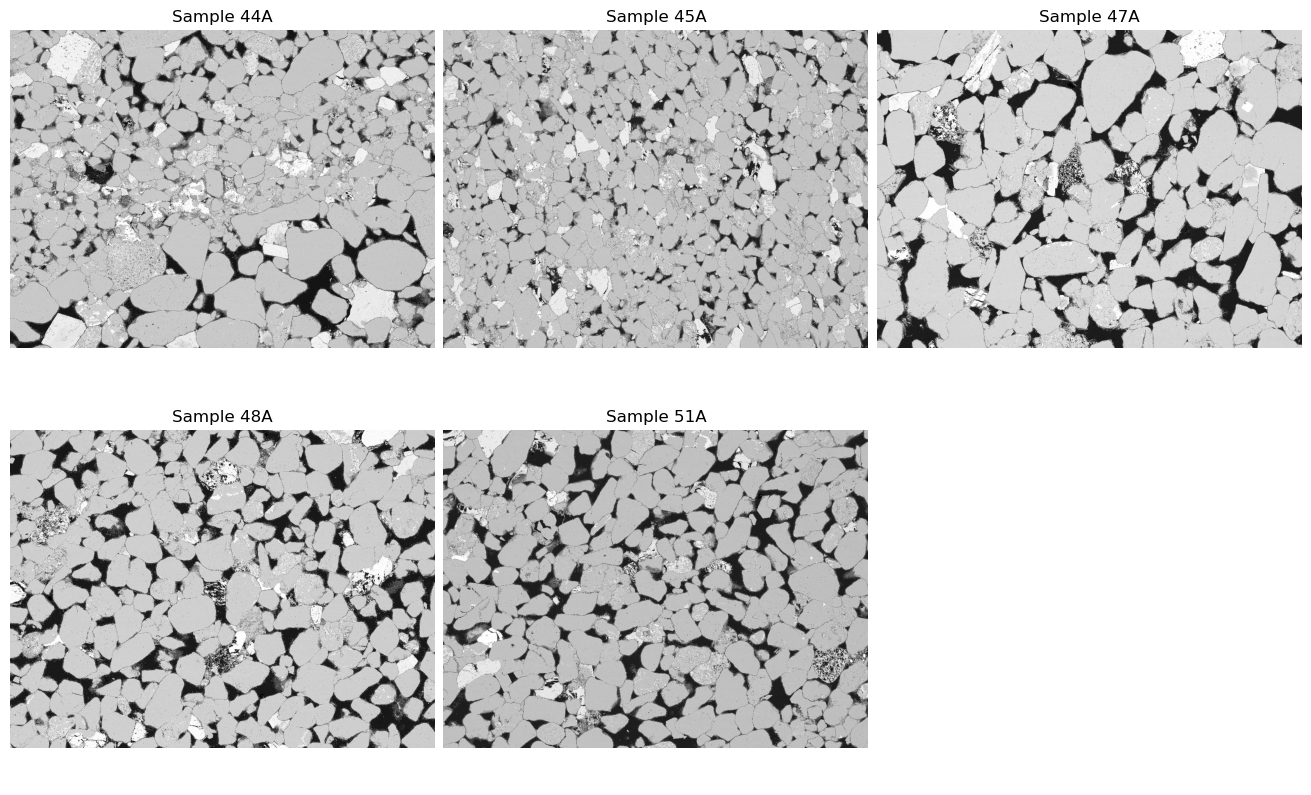

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)

for ax, sample_id in zip(axes.flat, sample_ids):
    ax.imshow(previews[sample_id], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Sample {sample_id}")
    ax.axis("off")

for ax in axes.flat[len(sample_ids):]:
    ax.axis("off")

fig.savefig(figures_dir / "sem-samples.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

## Intensity Distribution Analysis

Intensity histograms are computed from all original pixels, without downsampling. Comparing their shapes helps identify contrast differences and assess whether a single global threshold is likely to behave consistently across samples. Dark intensities are potential pore-space candidates, but intensity alone does not establish pore identity.

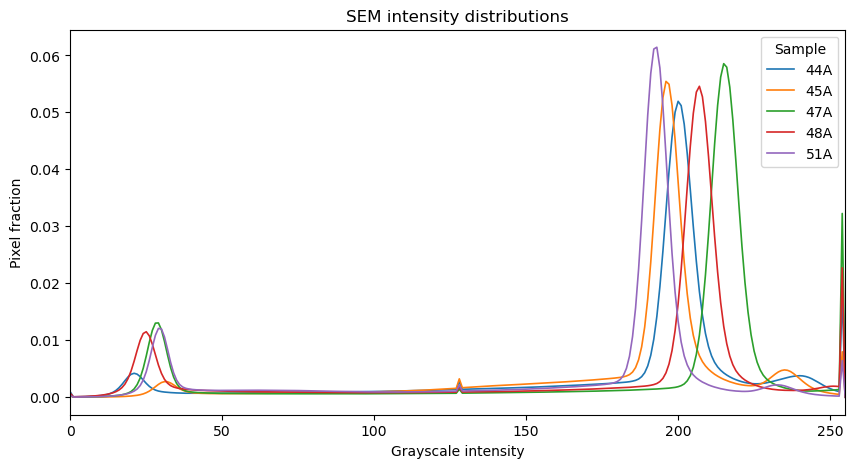

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
intensity = np.arange(256)

for sample_id in sample_ids:
    counts = histograms[sample_id]
    ax.plot(intensity, counts / counts.sum(), label=sample_id, linewidth=1.2)

ax.set(xlabel="Grayscale intensity", ylabel="Pixel fraction",
       title="SEM intensity distributions", xlim=(0, 255))
ax.legend(title="Sample")
fig.savefig(figures_dir / "intensity-distributions.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

## Intensity Summary

Intensity statistics are obtained directly from the full-resolution histograms. They describe image brightness and contrast, not pore fraction. Differences may reflect both material composition and imaging conditions.

In [6]:
def histogram_quantile(counts, probability):
    """
    Return an intensity quantile from pixel counts.

    Inputs
    ------
    counts : ndarray
        Counts for grayscale intensities 0 through 255.
    probability : float
        Quantile between zero and one.

    Outputs
    -------
    value : int
        Grayscale intensity at the requested quantile.
    """
    cumulative = np.cumsum(counts)
    return int(np.searchsorted(cumulative, probability * cumulative[-1]))


summary = []
for sample_id in sample_ids:
    counts = histograms[sample_id]
    weights = counts / counts.sum()
    mean = np.dot(intensity, weights)
    std = np.sqrt(np.dot((intensity - mean) ** 2, weights))

    summary.append({
        "sample": sample_id,
        "mean_intensity": round(float(mean), 2),
        "std_intensity": round(float(std), 2),
        "p05": histogram_quantile(counts, 0.05),
        "median": histogram_quantile(counts, 0.50),
        "p95": histogram_quantile(counts, 0.95),
    })

intensity_df = pd.DataFrame(summary)
intensity_df.to_csv(tables_dir / "intensity-summary.csv", index=False)
display(intensity_df)

,sample,mean_intensity,std_intensity,p05,median,p95
0,44A,181.96,52.89,38,199,240
1,45A,182.08,44.52,69,195,234
2,47A,184.52,66.89,28,214,238
3,48A,174.00,67.37,24,205,235
4,51A,164.09,59.33,29,191,215


## Image Preprocessing Assessment

Native-resolution central crops are inspected before any transformation is applied. The grayscale images have sufficient contrast for the initial segmentation comparison, so no Gaussian smoothing, contrast enhancement, or denoising is applied. Crops are diagnostic views rather than representative subsamples of the whole image.

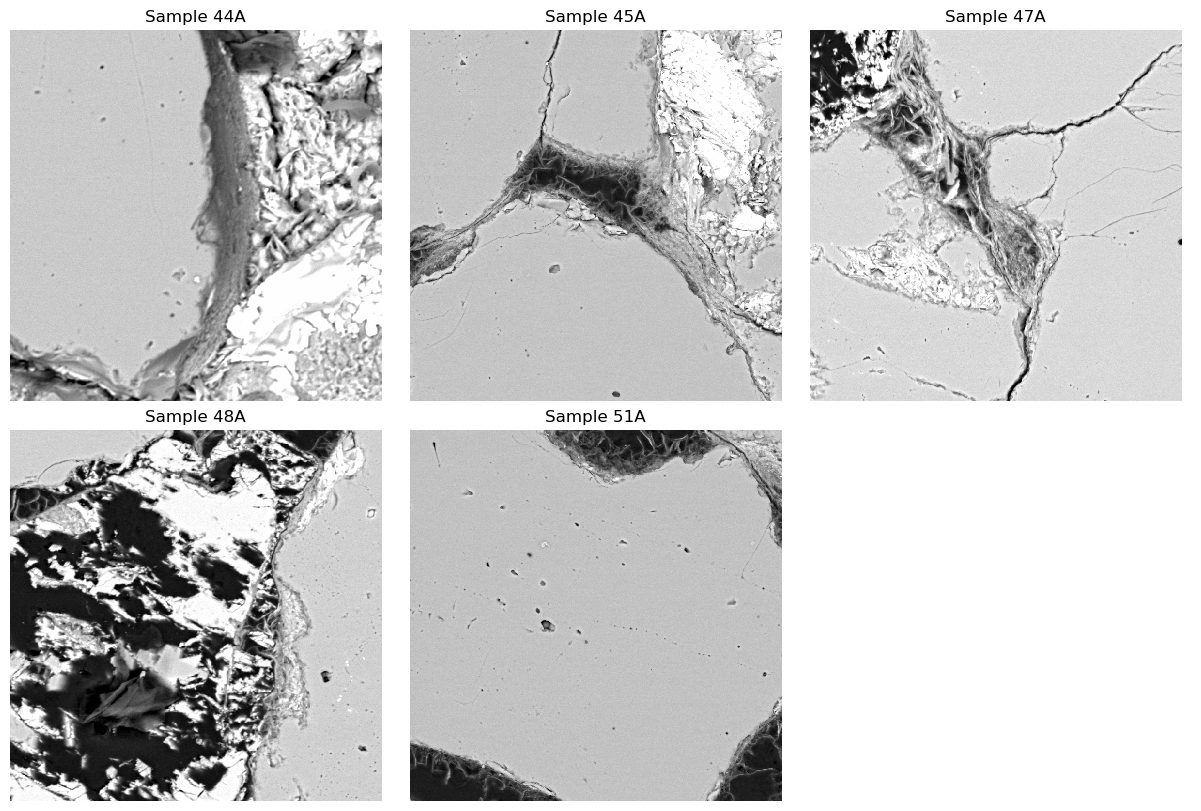

In [7]:
# Display central crops at native resolution
crop_size = 768
fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)

for ax, sample_id in zip(axes.flat, sample_ids):
    path = image_dir / f"Sample {sample_id} SEM" / image_names[sample_id]
    with Image.open(path) as source:
        width, height = source.size
        left = (width - crop_size) // 2
        top = (height - crop_size) // 2
        crop = np.asarray(source.crop((left, top, left + crop_size,
                                       top + crop_size)))

    if crop.ndim != 2:
        raise ValueError(f"Unexpected crop channels: {sample_id}")

    ax.imshow(crop, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set_title(f"Sample {sample_id}")
    ax.axis("off")

for ax in axes.flat[len(sample_ids):]:
    ax.axis("off")

fig.savefig(figures_dir / "central-crops.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

## Preliminary Assessment

The original grayscale intensities are retained for segmentation. The central crops help identify fine structures that are not resolved in the full-image previews; they do not establish whether every dark structure is pore space.

## Pore Space Segmentation

Dark pixels in BSE-SEM images are potential pore-space candidates but may also represent low-intensity minerals or imaging effects. Two image-specific thresholds are compared: Otsu's between-class variance criterion and a valley between dark and bright intensity peaks. Neither mask is treated as ground truth.

In [8]:
def otsu_threshold(counts):
    """
    Find the threshold that maximises between-class variance.

    Inputs
    ------
    counts : ndarray
        Histogram counts for intensities 0 to 255.

    Outputs
    -------
    threshold : int
        Otsu threshold in grayscale units.
    """
    probability = counts.astype(np.float64) / counts.sum()
    cumulative = np.cumsum(probability)
    cumulative_mean = np.cumsum(np.arange(256) * probability)
    total_mean = cumulative_mean[-1]

    denominator = cumulative * (1.0 - cumulative)
    variance = np.zeros(256, dtype=np.float64)
    valid = denominator > 0
    variance[valid] = (
        (total_mean * cumulative[valid] - cumulative_mean[valid]) ** 2
        / denominator[valid]
    )
    return int(np.argmax(variance[:-1]))


def valley_threshold(counts, dark_range=(5, 70), bright_range=(160, 235)):
    """
    Find a smoothed histogram valley between dark and bright peaks.

    Inputs
    ------
    counts : ndarray
        Histogram counts for intensities 0 to 255.
    dark_range : tuple
        Search interval for the dark peak, upper bound excluded.
    bright_range : tuple
        Search interval for the bright peak, upper bound excluded.

    Outputs
    -------
    threshold : int
        Minimum between the selected intensity peaks.
    """
    smooth = gaussian_filter1d(counts.astype(np.float64), sigma=2)
    dark_peak = dark_range[0] + np.argmax(smooth[slice(*dark_range)])
    bright_peak = bright_range[0] + np.argmax(smooth[slice(*bright_range)])
    if dark_peak >= bright_peak:
        raise ValueError("Dark peak must precede bright peak.")
    return int(dark_peak + np.argmin(smooth[dark_peak:bright_peak + 1]))


threshold_records = []
for sample_id in sample_ids:
    counts = histograms[sample_id]
    threshold_records.append({
        "sample": sample_id,
        "otsu": otsu_threshold(counts),
        "valley": valley_threshold(counts),
    })

threshold_df = pd.DataFrame(threshold_records).set_index("sample")
threshold_df.to_csv(tables_dir / "segmentation-thresholds.csv")
display(threshold_df)

,otsu,valley
sample,,
44A,135,43
45A,141,51
47A,130,77
48A,126,98
51A,121,107


## Threshold Comparison

The histogram-based threshold is determined from a smoothed histogram, with search intervals chosen to capture the two peaks observed in these five images. These intervals are dataset-specific assumptions, not a general pore segmentation rule. The vertical lines show how the two thresholds relate to each full-resolution intensity distribution.

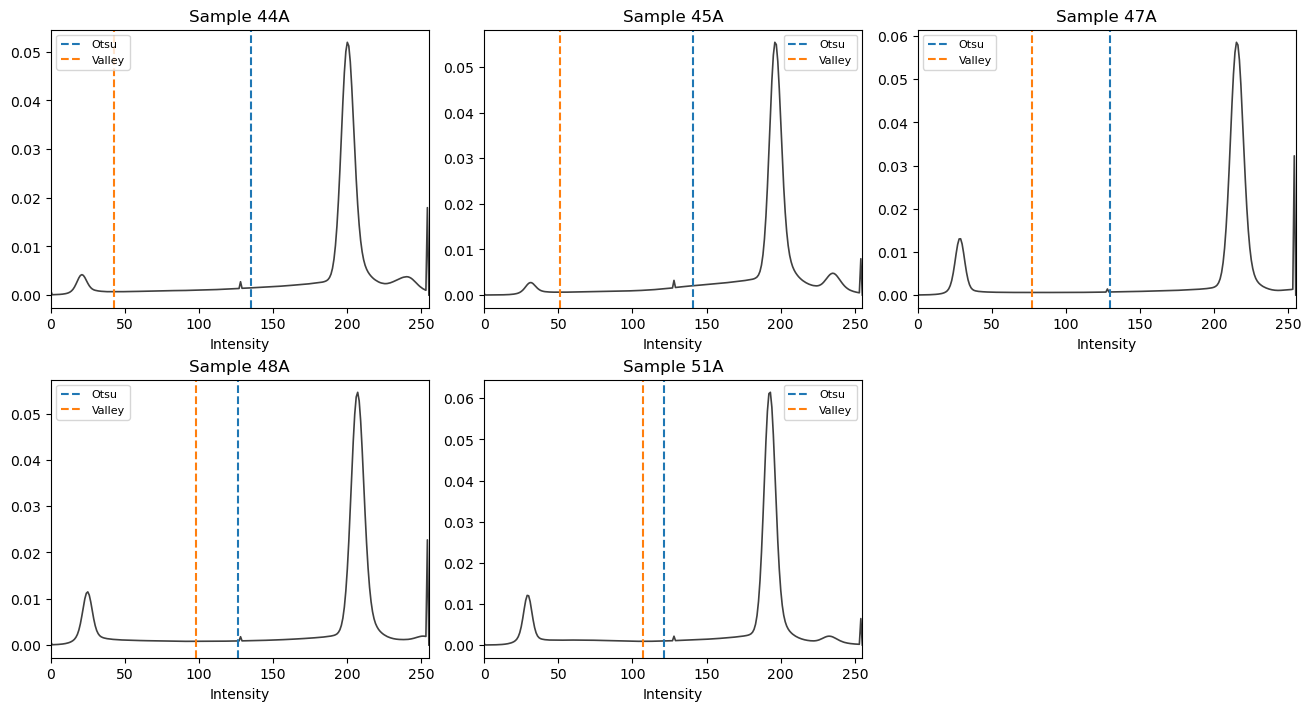

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)

for ax, sample_id in zip(axes.flat, sample_ids):
    counts = histograms[sample_id]
    ax.plot(np.arange(256), counts / counts.sum(), color="0.25", linewidth=1.2)
    ax.axvline(threshold_df.loc[sample_id, "otsu"], color="tab:blue",
               linestyle="--", label="Otsu")
    ax.axvline(threshold_df.loc[sample_id, "valley"], color="tab:orange",
               linestyle="--", label="Valley")
    ax.set(title=f"Sample {sample_id}", xlabel="Intensity", xlim=(0, 255))
    ax.legend(fontsize=8)

for ax in axes.flat[len(sample_ids):]:
    ax.axis("off")

fig.savefig(figures_dir / "threshold-comparison.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

## Segmentation Assessment on Native-Resolution Crops

Three native-resolution crops are selected at fixed relative positions (one-quarter, centre, and three-quarters of the image width and height). The same centre points are used later for the larger morphological crops. Pixels at or below the threshold are assigned to the dark class; the masks are not validated pore labels.

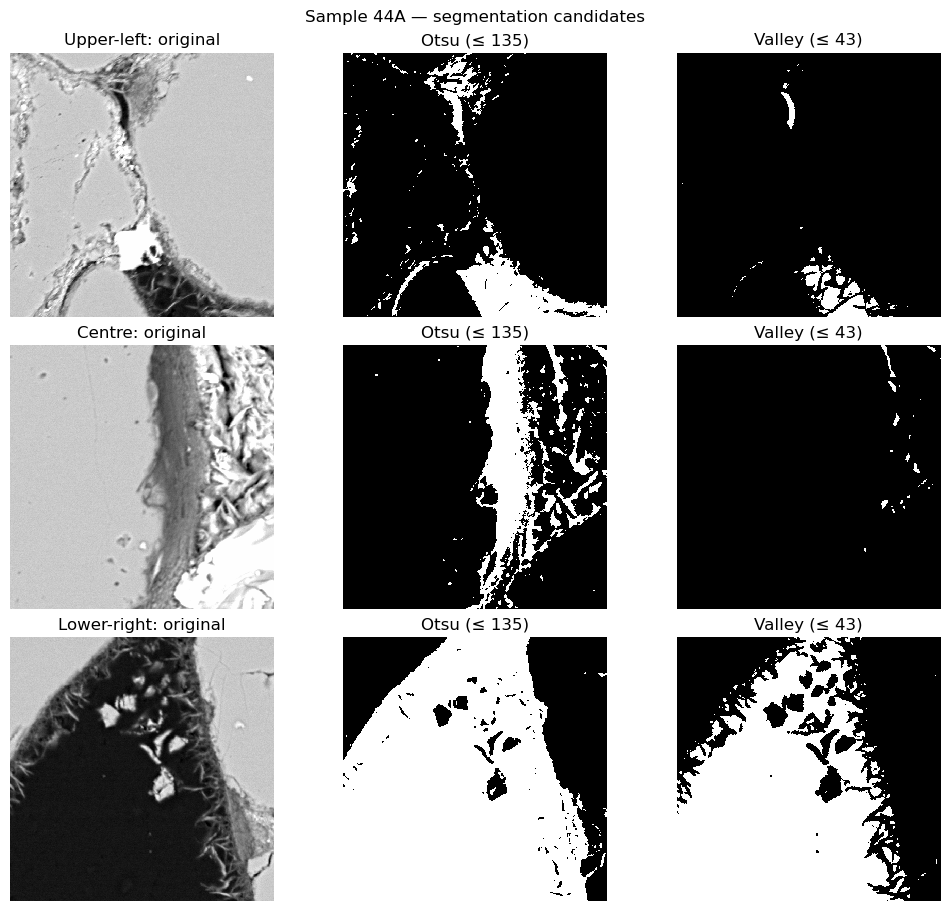

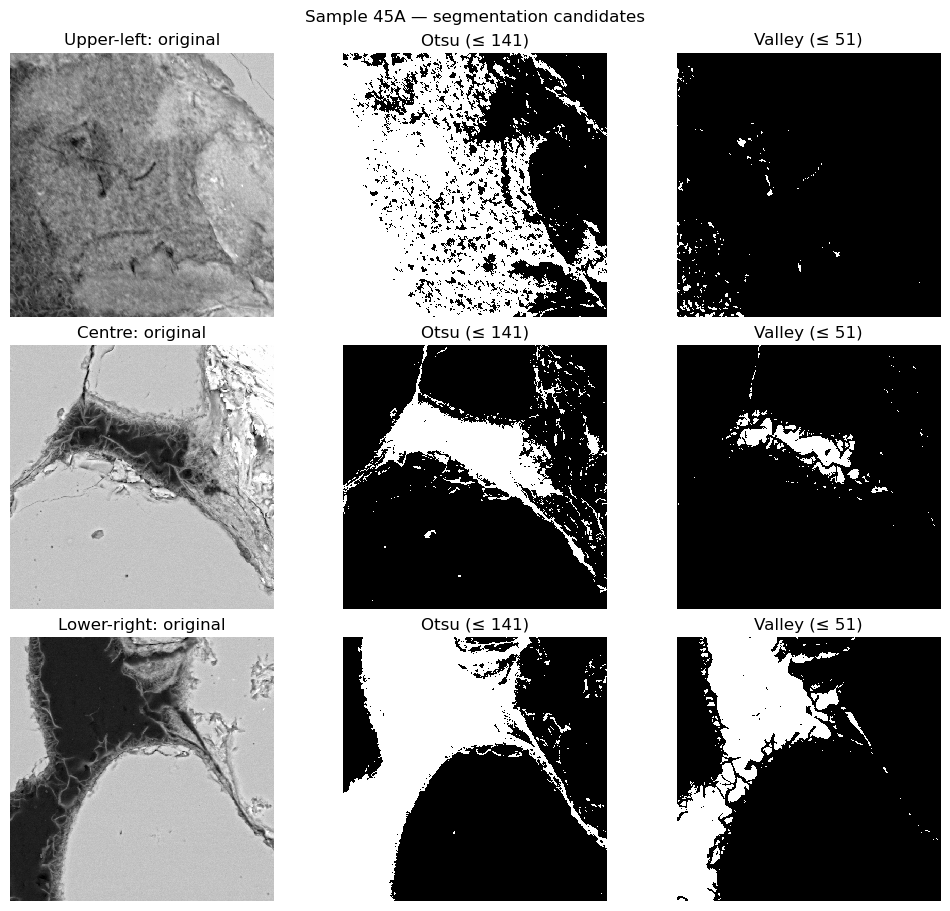

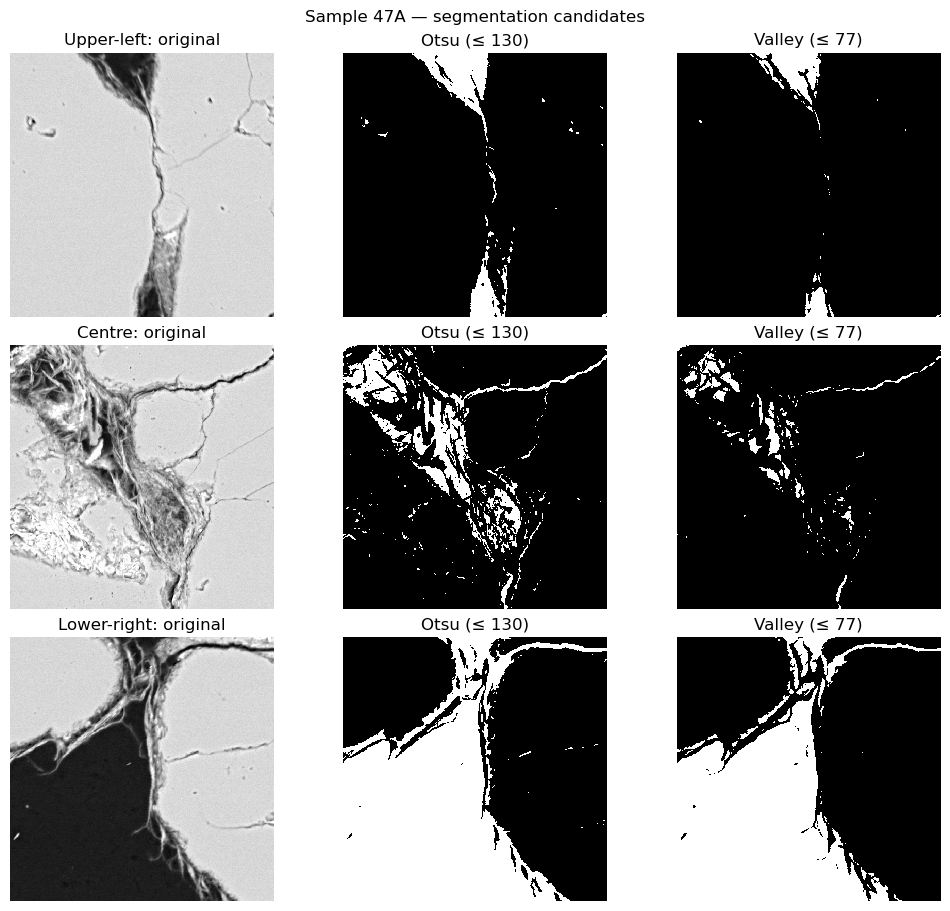

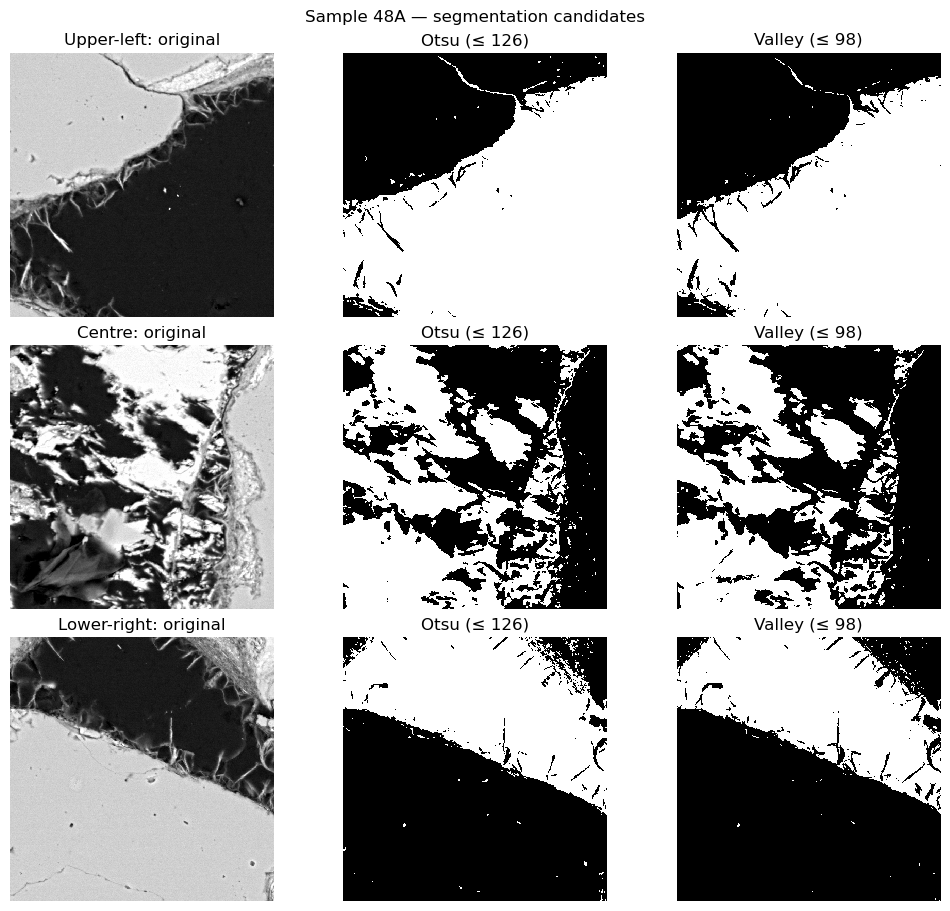

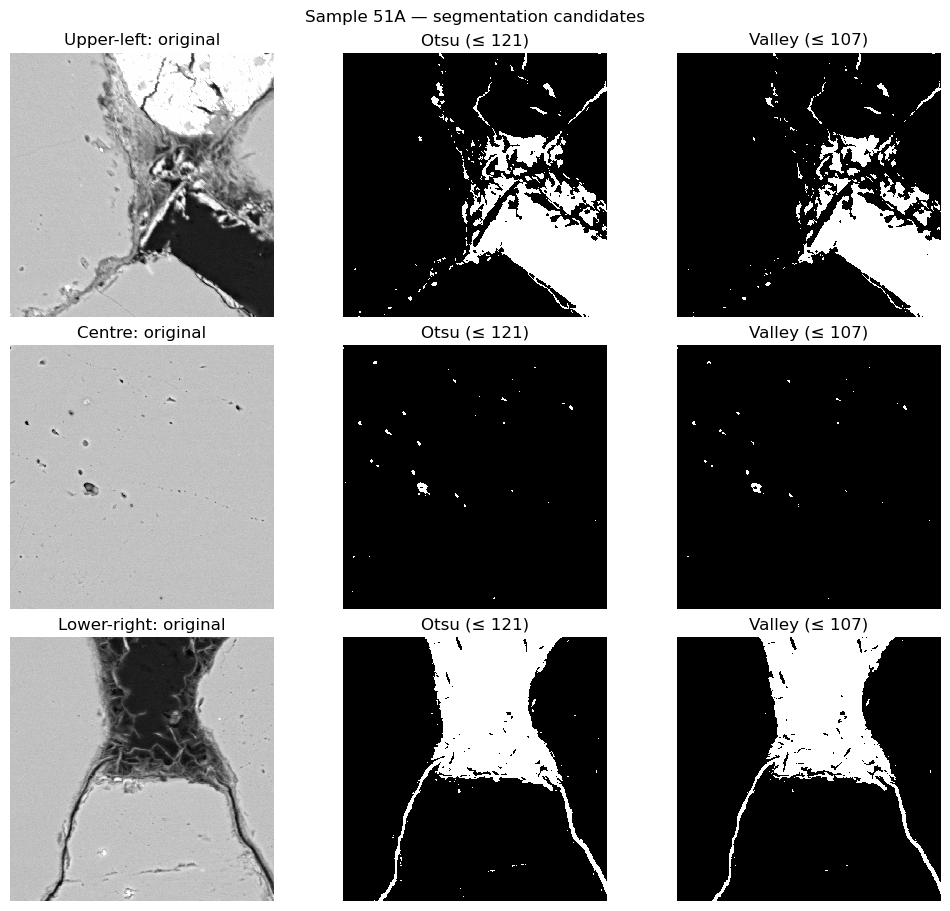

In [10]:
def crop_bounds(height, width, size, position):
    """
    Return boundaries for a crop centred at a fixed image position.

    Inputs
    ------
    height, width : int
        Original image dimensions in pixels.
    size : int
        Square crop side length in pixels.
    position : str
        One of upper-left, centre, or lower-right.

    Outputs
    -------
    bounds : tuple
        Row and column boundaries (r0, r1, c0, c1).
    """
    centres = {
        "upper-left": (height // 4, width // 4),
        "centre": (height // 2, width // 2),
        "lower-right": (3 * height // 4, 3 * width // 4),
    }
    if position not in centres:
        raise ValueError(f"Unknown crop position: {position}")
    if size > min(height, width):
        raise ValueError("Crop size exceeds image dimensions.")

    row_centre, col_centre = centres[position]
    row = min(max(row_centre - size // 2, 0), height - size)
    col = min(max(col_centre - size // 2, 0), width - size)
    return row, row + size, col, col + size


def read_crops(path, crop_size=512):
    """
    Read three native-resolution image crops.

    Inputs
    ------
    path : Path
        Original PNG image path.
    crop_size : int
        Square crop side length in pixels.

    Outputs
    -------
    crops : dict
        Grayscale arrays indexed by their position.
    """
    with Image.open(path) as source:
        width, height = source.size
        crops = {}
        for position in ("upper-left", "centre", "lower-right"):
            r0, r1, c0, c1 = crop_bounds(height, width, crop_size, position)
            crops[position] = np.asarray(
                source.crop((c0, r0, c1, r1))
            ).copy()
    return crops


for sample_id in sample_ids:
    path = image_dir / f"Sample {sample_id} SEM" / image_names[sample_id]
    crops = read_crops(path)
    otsu = int(threshold_df.loc[sample_id, "otsu"])
    valley = int(threshold_df.loc[sample_id, "valley"])

    fig, axes = plt.subplots(3, 3, figsize=(10, 9), constrained_layout=True)
    for row, (position, crop) in enumerate(crops.items()):
        views = (crop, crop <= otsu, crop <= valley)
        for col, view in enumerate(views):
            axes[row, col].imshow(
                view, cmap="gray", vmin=0, vmax=255 if col == 0 else 1,
                interpolation="nearest"
            )
            axes[row, col].axis("off")
        axes[row, 0].set_title(f"{position.capitalize()}: original")
        axes[row, 1].set_title(f"Otsu (≤ {otsu})")
        axes[row, 2].set_title(f"Valley (≤ {valley})")

    fig.suptitle(f"Sample {sample_id} — segmentation candidates")
    fig.savefig(figures_dir / f"segmentation-{sample_id.lower()}.png",
                dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Threshold Sensitivity

The fraction of pixels classified as dark is evaluated for thresholds five grayscale levels below and above each candidate threshold. This is a local sensitivity check on the selected crops, not a full-image pore fraction or an estimate of laboratory porosity. Differences between crop positions also illustrate spatial heterogeneity; the crops are not independent geological samples.

In [11]:
sensitivity_records = []

for sample_id in sample_ids:
    path = image_dir / f"Sample {sample_id} SEM" / image_names[sample_id]
    crops = read_crops(path)

    for method in ("otsu", "valley"):
        reference = int(threshold_df.loc[sample_id, method])
        for position, crop in crops.items():
            for offset in (-5, 0, 5):
                threshold = int(np.clip(reference + offset, 0, 255))
                sensitivity_records.append({
                    "sample": sample_id,
                    "position": position,
                    "method": method,
                    "threshold": threshold,
                    "offset": offset,
                    "dark_fraction": float(np.mean(crop <= threshold)),
                })

sensitivity_df = pd.DataFrame(sensitivity_records)
sensitivity_df.to_csv(tables_dir / "threshold-sensitivity.csv", index=False)
display(sensitivity_df.pivot_table(
    index=["sample", "method", "position"],
    columns="offset", values="dark_fraction"
).round(3))

offset                        -5      0      5
sample method position                        
44A    otsu   centre       0.155  0.171  0.185
              lower-right  0.707  0.711  0.716
              upper-left   0.098  0.105  0.112
       valley centre       0.005  0.005  0.006
              lower-right  0.523  0.537  0.551
              upper-left   0.025  0.028  0.031
45A    otsu   centre       0.150  0.160  0.170
              lower-right  0.376  0.383  0.390
              upper-left   0.536  0.596  0.647
       valley centre       0.035  0.041  0.047
              lower-right  0.226  0.236  0.245
              upper-left   0.007  0.012  0.017
47A    otsu   centre       0.098  0.109  0.119
              lower-right  0.436  0.441  0.445
              upper-left   0.053  0.056  0.059
       valley centre       0.033  0.037  0.041
              lower-right  0.394  0.399  0.403
              upper-left   0.031  0.033  0.035
48A    otsu   centre       0.464  0.472  0.482
              lower-right  0.381  0.386  0.392
              upper-left   0.630  0.633  0.637
       valley centre       0.416  0.425  0.434
              lower-right  0.354  0.358  0.363
              upper-left   0.611  0.614  0.618
51A    otsu   centre       0.003  0.003  0.004
              lower-right  0.224  0.228  0.232
              upper-left   0.191  0.199  0.207
       valley centre       0.002  0.003  0.003
              lower-right  0.212  0.216  0.220
              upper-left   0.170  0.177  0.185

## Assessment of Segmentation Candidates

The full-image area comparison below complements the native-resolution masks. Differences between the two thresholding methods indicate segmentation uncertainty. Visual comparison and numerical stability alone cannot establish the true pore class.

## Full-Image Segmentation Assessment

The two candidate thresholds are now evaluated using the full-resolution intensity histograms. Because each mask is defined solely by an intensity cutoff, its area fraction can be calculated exactly from histogram counts without allocating another 201-million-pixel image. The resulting **dark-region fraction** is not yet a validated pore fraction.

In [12]:
def dark_fraction(counts, threshold):
    """
    Calculate the fraction of pixels at or below a threshold.

    Inputs
    ------
    counts : ndarray
        Full-image counts for grayscale intensities 0 to 255.
    threshold : int
        Inclusive upper intensity threshold.

    Outputs
    -------
    fraction : float
        Fraction of image pixels classified as dark.
    """
    return float(counts[:int(threshold) + 1].sum() / counts.sum())


fraction_records = []
for sample_id in sample_ids:
    for method in ("otsu", "valley"):
        threshold = int(threshold_df.loc[sample_id, method])
        fraction_records.append({
            "sample": sample_id,
            "method": method,
            "threshold": threshold,
            "dark_fraction": dark_fraction(histograms[sample_id], threshold),
        })

full_fraction_df = pd.DataFrame(fraction_records)
full_fraction_df.to_csv(tables_dir / "full-image-fractions.csv", index=False)
display(full_fraction_df)

,sample,method,threshold,dark_fraction
0,44A,otsu,135,0.146761
1,44A,valley,43,0.054106
2,45A,otsu,141,0.136079
3,45A,valley,51,0.037896
4,47A,otsu,130,0.176532
5,47A,valley,77,0.142256
6,48A,otsu,126,0.199735
7,48A,valley,98,0.176356
8,51A,otsu,121,0.195509
9,51A,valley,107,0.182281


## Comparison with Laboratory Porosity

Helium porosity provides independent bulk measurements for the five samples. The image-derived values are **two-dimensional dark-pixel area fractions**, whereas helium porosity is a bulk volume fraction. They differ in measurement support, resolution and physical meaning. In particular, mineral phases and imaging artefacts may also appear dark, and unresolved microporosity may not be visible in the SEM images. The comparison is diagnostic; the thresholds are not calibrated to reproduce laboratory values.

method,sample,otsu_area_pct,valley_area_pct,helium_porosity_pct
0,44A,14.676150,5.410578,12.8
1,45A,13.607855,3.789586,10.8
2,47A,17.653162,14.225570,17.4
3,48A,19.973471,17.635575,20.1
4,51A,19.550912,18.228121,17.7


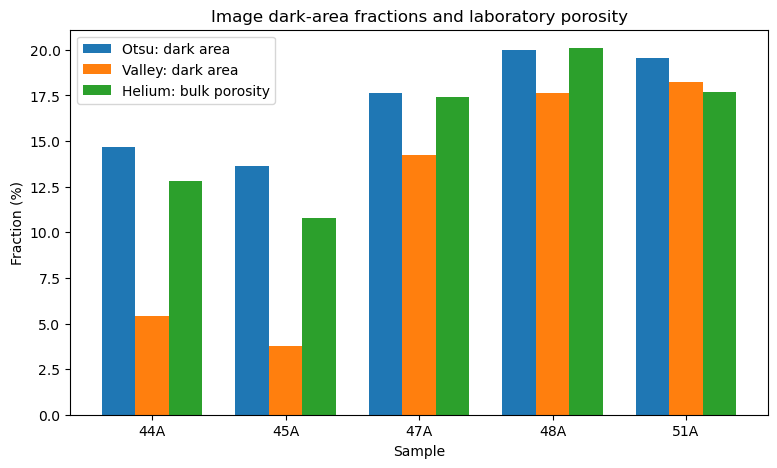

In [13]:
# Helium porosity (%) reported in the DRP-307 dataset metadata
helium_porosity = {
    "44A": 12.8,
    "45A": 10.8,
    "47A": 17.4,
    "48A": 20.1,
    "51A": 17.7,
}

comparison_df = full_fraction_df.pivot(
    index="sample", columns="method", values="dark_fraction"
).reindex(sample_ids)
comparison_df = comparison_df.rename(columns={
    "otsu": "otsu_area_pct", "valley": "valley_area_pct"
}) * 100
comparison_df["helium_porosity_pct"] = pd.Series(helium_porosity)
comparison_df = comparison_df.reset_index()
comparison_df.to_csv(tables_dir / "porosity-comparison.csv", index=False)
display(comparison_df)

x = np.arange(len(sample_ids))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, comparison_df["otsu_area_pct"], width, label="Otsu: dark area")
ax.bar(x, comparison_df["valley_area_pct"], width, label="Valley: dark area")
ax.bar(x + width, comparison_df["helium_porosity_pct"], width,
       label="Helium: bulk porosity")
ax.set(xlabel="Sample", ylabel="Fraction (%)",
       title="Image dark-area fractions and laboratory porosity")
ax.set_xticks(x, sample_ids)
ax.legend()
fig.savefig(figures_dir / "porosity-comparison.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

## Full-Image Threshold Sensitivity

For each method, the dark-region fraction is recalculated at thresholds five grayscale levels below and above the reference. This uses the same full-resolution histograms and introduces no additional image-memory overhead. The range measures sensitivity to threshold choice, **not segmentation accuracy**.

,sample,method,offset,threshold,dark_fraction
0,44A,otsu,-5,130,0.139490
1,44A,otsu,0,135,0.146761
2,44A,otsu,5,140,0.154402
3,44A,valley,-5,38,0.050643
4,44A,valley,0,43,0.054106
5,44A,valley,5,48,0.057581
6,45A,otsu,-5,136,0.126087
7,45A,otsu,0,141,0.136079
8,45A,otsu,5,146,0.146804
9,45A,valley,-5,46,0.034723


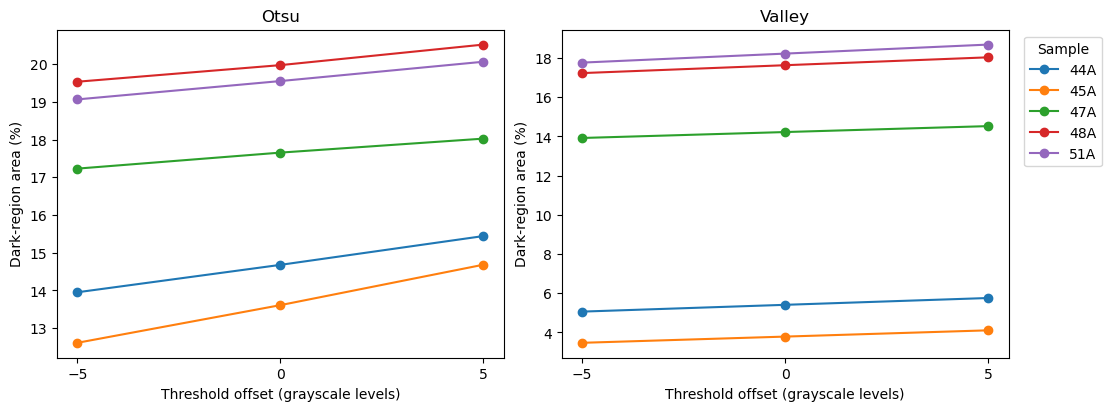

In [14]:
full_sensitivity_records = []
for sample_id in sample_ids:
    counts = histograms[sample_id]
    for method in ("otsu", "valley"):
        reference = int(threshold_df.loc[sample_id, method])
        for offset in (-5, 0, 5):
            threshold = int(np.clip(reference + offset, 0, 255))
            full_sensitivity_records.append({
                "sample": sample_id,
                "method": method,
                "offset": offset,
                "threshold": threshold,
                "dark_fraction": dark_fraction(counts, threshold),
            })

full_sensitivity_df = pd.DataFrame(full_sensitivity_records)
full_sensitivity_df.to_csv(
    tables_dir / "full-image-sensitivity.csv", index=False
)
display(full_sensitivity_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, method in zip(axes, ("otsu", "valley")):
    for sample_id in sample_ids:
        subset = full_sensitivity_df.loc[
            (full_sensitivity_df["sample"] == sample_id)
            & (full_sensitivity_df["method"] == method)
        ].sort_values("offset")
        ax.plot(subset["offset"], 100 * subset["dark_fraction"],
                marker="o", label=sample_id)
    ax.set(xlabel="Threshold offset (grayscale levels)",
           ylabel="Dark-region area (%)", title=method.capitalize())
    ax.set_xticks([-5, 0, 5])
axes[1].legend(title="Sample", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.savefig(figures_dir / "full-image-sensitivity.png", dpi=180,
            bbox_inches="tight")
plt.show()
plt.close(fig)

## Segmentation Choice

Otsu is retained as a reproducible, image-specific **operational dark-region segmentation** for the remaining measurements. The valley method is preserved as a contrasting interpretation of the intensity distributions. Agreement between an image dark-area fraction and bulk helium porosity is not a validation of pore identity; no threshold is calibrated to reproduce laboratory measurements.

## Morphological Characterisation

Morphological measurements are made on three 1024 × 1024-pixel crops per sample, centred at the same relative positions used in the earlier mask inspection. Eight-connected components describe dark regions in two dimensions. Only fully contained components enter the area distribution: this avoids measuring truncated objects but preferentially excludes larger components that intersect crop borders. The distance transform describes distances of **dark pixels** to the nearest light pixel, not pore-throat radii or pore sizes.

In [15]:
crop_size = 1024
crop_positions = ("upper-left", "centre", "lower-right")


def measure_crop(mask, pixel_size_um):
    """
    Measure connected dark regions within one crop.

    Inputs
    ------
    mask : ndarray
        Two-dimensional Boolean segmentation mask.
    pixel_size_um : float
        Pixel spacing in micrometres.

    Outputs
    -------
    measurements : dict
        Dark-area fraction, component counts, and distance metrics.
    """
    labels, count = ndi.label(mask, structure=ndi.generate_binary_structure(2, 2))
    areas = np.bincount(labels.ravel(), minlength=count + 1)[1:]
    border_labels = np.unique(np.concatenate((
        labels[0, :], labels[-1, :], labels[:, 0], labels[:, -1]
    )))
    valid = np.ones(count + 1, dtype=bool)
    valid[0] = False
    valid[border_labels] = False
    interior_areas = areas[valid[1:]]

    # The padded background prevents distance values extending beyond the crop.
    distance = ndi.distance_transform_edt(
        np.pad(mask, 1, constant_values=False)
    )[1:-1, 1:-1]
    dark_distances = distance[mask] * pixel_size_um

    return {
        "dark_fraction": float(mask.mean()),
        "component_count": int(count),
        "interior_component_count": int(interior_areas.size),
        "median_component_area_um2": (
            float(np.median(interior_areas) * pixel_size_um ** 2)
            if interior_areas.size else np.nan
        ),
        "p90_component_area_um2": (
            float(np.percentile(interior_areas, 90) * pixel_size_um ** 2)
            if interior_areas.size else np.nan
        ),
        "median_distance_um": (
            float(np.median(dark_distances)) if dark_distances.size else np.nan
        ),
        "p90_distance_um": (
            float(np.percentile(dark_distances, 90)) if dark_distances.size else np.nan
        ),
    }

### Local Morphological Measurements

The local analysis reports the dark-area fraction, size of fully contained connected components, and the distribution of Euclidean distances from dark pixels to light pixels. Component areas describe binary image objects, not necessarily individual geological pore bodies. Padding the mask with light pixels ensures a finite distance transform, but affects distances near crop boundaries.

A small threshold sensitivity test (Otsu ±5 grayscale levels) will be performed on **the same crops**, without changing the image-processing method. The three positions are diagnostics within each image, not independent geological specimens.

In [16]:
morphology_records = []

for sample_id in sample_ids:
    path = image_dir / f"Sample {sample_id} SEM" / image_names[sample_id]
    image, _ = load_grayscale(path)
    reference = int(threshold_df.loc[sample_id, "otsu"])
    pixel_size_um = float(
        sample_info.set_index("sample").loc[sample_id, "pixel_x_um"]
    )
    height, width = image.shape

    for position in crop_positions:
        r0, r1, c0, c1 = crop_bounds(height, width, crop_size, position)
        crop = image[r0:r1, c0:c1]
        for offset in (-5, 0, 5):
            threshold = int(np.clip(reference + offset, 0, 255))
            measurements = measure_crop(crop <= threshold, pixel_size_um)
            morphology_records.append({
                "sample": sample_id,
                "position": position,
                "offset": offset,
                "threshold": threshold,
                **measurements,
            })

    del image

morphology_sensitivity_df = pd.DataFrame(morphology_records)
morphology_sensitivity_df.to_csv(
    tables_dir / "morphology-sensitivity.csv", index=False
)
morphology_df = morphology_sensitivity_df.loc[
    morphology_sensitivity_df["offset"] == 0
].drop(columns="offset").copy()
morphology_df.to_csv(tables_dir / "local-morphology.csv", index=False)
display(morphology_df)

,sample,position,threshold,dark_fraction,component_count,interior_component_count,median_component_area_um2,p90_component_area_um2,median_distance_um,p90_distance_um
1,44A,upper-left,135,0.180366,526,501,0.181656,1.544076,0.870000,3.198951
4,44A,centre,135,0.158060,716,687,0.151380,2.646122,0.696000,2.880212
7,44A,lower-right,135,0.428841,123,121,0.242208,2.755116,5.311989,24.236645
10,45A,upper-left,141,0.372853,1195,1167,0.090828,1.132322,1.218000,8.416997
13,45A,centre,141,0.082203,1781,1739,0.121104,1.150488,0.389076,2.958000
16,45A,lower-right,141,0.259953,879,853,0.090828,1.053605,1.774459,8.021004
19,47A,upper-left,130,0.133068,121,115,0.333036,1.477469,2.473005,12.140163
22,47A,centre,130,0.102362,849,818,0.151380,1.877112,0.550236,2.288613
25,47A,lower-right,130,0.393252,273,260,0.181656,1.880140,6.371822,17.400000
28,48A,upper-left,126,0.393914,298,287,0.181656,1.544076,5.046000,20.892321


### Morphological Comparison

This figure shows the median area of fully contained dark components and the 90th percentile of dark-pixel distances for the three selected locations. Discrete markers distinguish separate specimens and separate crops; connecting different specimens with lines would imply an inappropriate ordering.

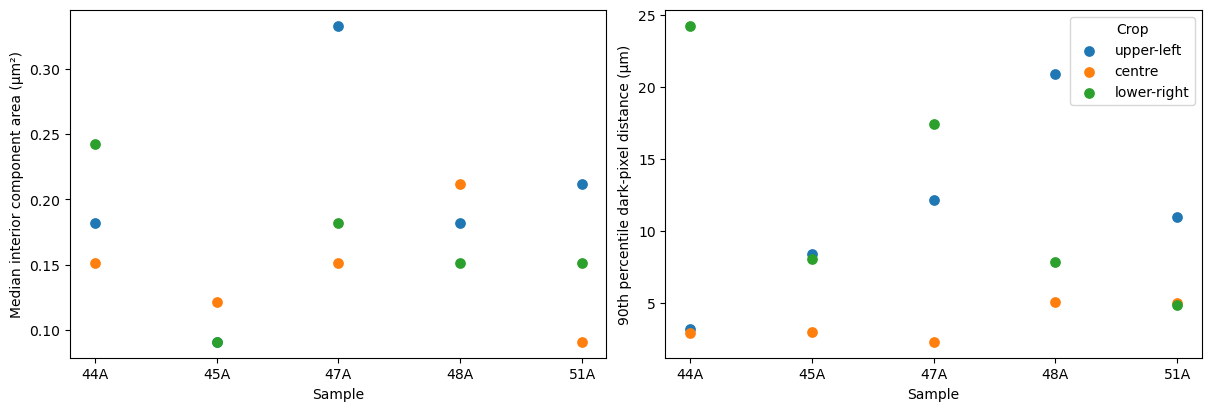

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
metrics = (
    ("median_component_area_um2", "Median interior component area (µm²)"),
    ("p90_distance_um", "90th percentile dark-pixel distance (µm)"),
)
for ax, (column, ylabel) in zip(axes, metrics):
    for position in crop_positions:
        subset = morphology_df.loc[
            morphology_df["position"] == position
        ].set_index("sample").reindex(sample_ids)
        ax.scatter(sample_ids, subset[column], label=position, s=45)
    ax.set(xlabel="Sample", ylabel=ylabel)
axes[1].legend(title="Crop")
fig.savefig(figures_dir / "local-morphology.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

### Morphological Threshold Sensitivity

The morphological descriptors are recalculated at Otsu −5, Otsu, and Otsu +5 on the **same native-resolution crops**. The curves below show how the individual local measurements change with the threshold. The 47A–51A comparison is of particular interest, but stability under ±5 levels cannot validate the pore classification or remove uncertainty from crop selection.

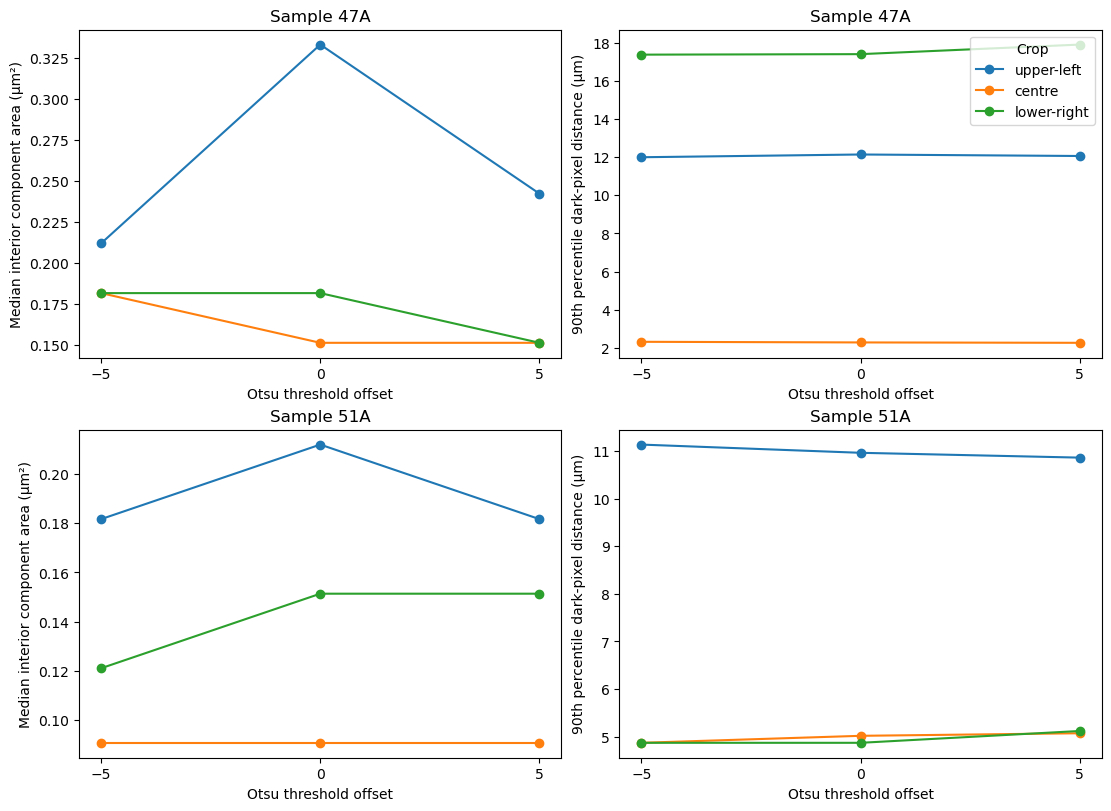

,sample,position,offset,dark_fraction,median_component_area_um2,p90_distance_um
18,47A,upper-left,-5,0.131,0.212,11.996
19,47A,upper-left,0,0.133,0.333,12.140
20,47A,upper-left,5,0.135,0.242,12.061
21,47A,centre,-5,0.097,0.182,2.321
22,47A,centre,0,0.102,0.151,2.289
23,47A,centre,5,0.107,0.151,2.269
24,47A,lower-right,-5,0.389,0.182,17.374
25,47A,lower-right,0,0.393,0.182,17.400
26,47A,lower-right,5,0.397,0.151,17.902
36,51A,upper-left,-5,0.182,0.182,11.136


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
metrics = (
    ("median_component_area_um2", "Median interior component area (µm²)"),
    ("p90_distance_um", "90th percentile dark-pixel distance (µm)"),
)

for row, sample_id in enumerate(("47A", "51A")):
    for col, (metric, ylabel) in enumerate(metrics):
        ax = axes[row, col]
        for position in crop_positions:
            subset = morphology_sensitivity_df.loc[
                (morphology_sensitivity_df["sample"] == sample_id)
                & (morphology_sensitivity_df["position"] == position)
            ].sort_values("offset")
            ax.plot(subset["offset"], subset[metric], marker="o",
                    label=position)
        ax.set(title=f"Sample {sample_id}", xlabel="Otsu threshold offset",
               ylabel=ylabel)
        ax.set_xticks([-5, 0, 5])

axes[0, 1].legend(title="Crop")
fig.savefig(figures_dir / "morphology-sensitivity.png", dpi=180,
            bbox_inches="tight")
plt.show()
plt.close(fig)

display(morphology_sensitivity_df.loc[
    morphology_sensitivity_df["sample"].isin(["47A", "51A"]),
    ["sample", "position", "offset", "dark_fraction",
     "median_component_area_um2", "p90_distance_um"]
].round(3))

## Spatial Heterogeneity

To complement the three detailed crops, the entire image is divided into non-overlapping 1024 × 1024-pixel tiles. Dark-area fraction is calculated at native resolution for every tile. This requires only one original image in memory at a time and does not require storing a full-size segmentation mask. Tiles are spatial subdivisions of a single specimen image, **not independent samples**.

In [19]:
tile_size = 1024
spatial_records = []
spatial_maps = {}

for sample_id in sample_ids:
    path = image_dir / f"Sample {sample_id} SEM" / image_names[sample_id]
    image, _ = load_grayscale(path)
    height, width = image.shape
    threshold = int(threshold_df.loc[sample_id, "otsu"])
    n_rows = (height + tile_size - 1) // tile_size
    n_cols = (width + tile_size - 1) // tile_size
    fraction_map = np.empty((n_rows, n_cols), dtype=float)

    for tile_row in range(n_rows):
        for tile_col in range(n_cols):
            r0, c0 = tile_row * tile_size, tile_col * tile_size
            tile = image[r0:min(r0 + tile_size, height),
                         c0:min(c0 + tile_size, width)]
            fraction = float(np.count_nonzero(tile <= threshold) / tile.size)
            fraction_map[tile_row, tile_col] = fraction
            spatial_records.append({
                "sample": sample_id,
                "tile_row": tile_row,
                "tile_col": tile_col,
                "dark_fraction": fraction,
            })

    spatial_maps[sample_id] = fraction_map
    del image

spatial_df = pd.DataFrame(spatial_records)
spatial_df.to_csv(tables_dir / "spatial-fractions.csv", index=False)
display(spatial_df.groupby("sample")["dark_fraction"].agg(
    ["min", "median", "max", "std"]
).reindex(sample_ids))

,min,median,max,std
sample,,,,
44A,0.003016,0.123342,0.658774,0.107816
45A,0.025983,0.125284,0.349719,0.065042
47A,0.000154,0.138357,0.817315,0.147687
48A,0.002810,0.180888,0.697964,0.124730
51A,0.019176,0.174511,0.646759,0.117344


### Spatial Distribution of Dark Regions

Each heatmap represents the fraction of dark pixels in a physical tile of approximately 178 × 178 µm. A common colour scale permits direct comparison. Tile boundaries are computational partitions, not geological boundaries.

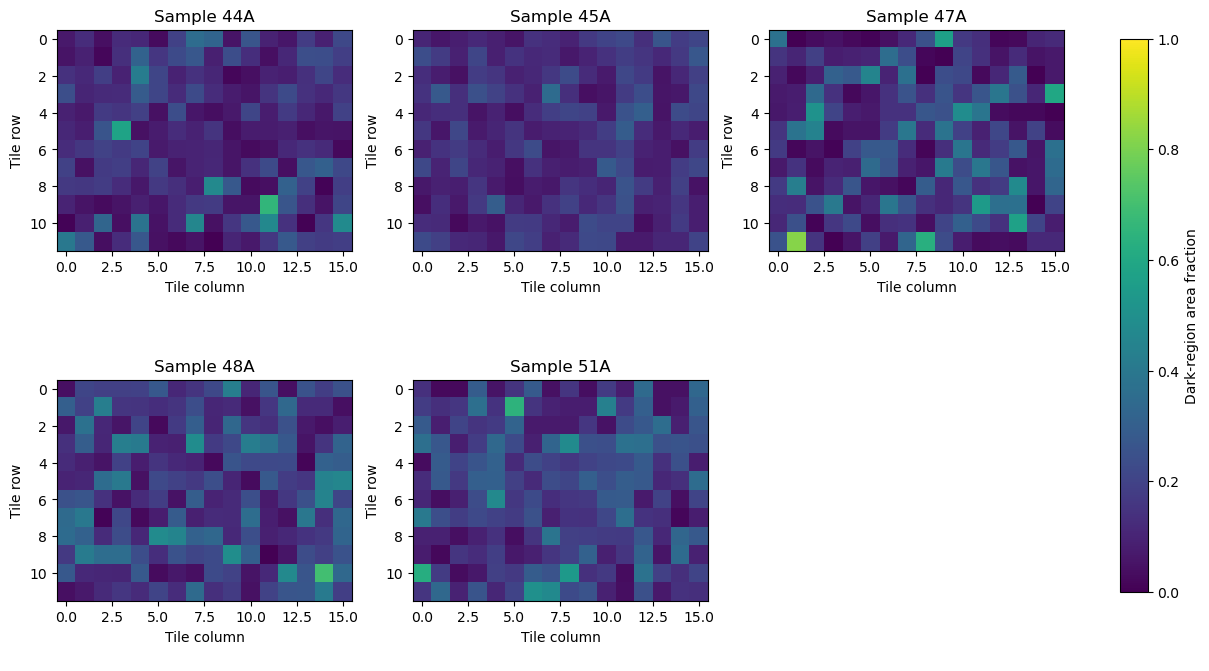

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
for ax, sample_id in zip(axes.flat, sample_ids):
    image_artist = ax.imshow(spatial_maps[sample_id], vmin=0, vmax=1,
                             cmap="viridis", interpolation="nearest")
    ax.set_title(f"Sample {sample_id}")
    ax.set(xlabel="Tile column", ylabel="Tile row")
for ax in axes.flat[len(sample_ids):]:
    ax.axis("off")
fig.colorbar(image_artist, ax=axes.ravel().tolist(), label="Dark-region area fraction",
             shrink=0.8)
fig.savefig(figures_dir / "spatial-heterogeneity.png", dpi=180,
            bbox_inches="tight")
plt.show()
plt.close(fig)

## Interpretation and Limitations

The Otsu masks define dark regions, not confirmed pores. Local component statistics exclude boundary-touching objects and therefore do not characterise all regions within a crop, particularly large ones. The artificially light exterior affects distance measurements near crop edges. The morphological sensitivity analysis tests only small perturbations of Otsu, and does not address segmentation ambiguity between Otsu and the valley method or uncertain geological representativeness. The full-image tile analysis quantifies within-image heterogeneity, not sample-level replication.

## Cross-Sample Comparison

The summary combines full-image Otsu dark-area fraction, variation among 1024 × 1024-pixel tiles, and morphological measurements on three fixed native-resolution crops. The crop measurements are descriptive and threshold-dependent; the full-image tile fractions are spatial subdivisions, not independent specimens. Comparisons with petrophysical properties are exploratory.

In [21]:
# Laboratory measurements reported in the DRP-307 dataset metadata
permeability_md = {"44A": 7.7, "45A": 1.1, "47A": 263.0, "48A": 58.0, "51A": 7.5}
formation_factor = {"44A": 35.2, "45A": 50.3, "47A": 21.4, "48A": 25.6, "51A": 28.7}

summary_records = []
for sample_id in sample_ids:
    tiles = spatial_df.loc[spatial_df["sample"] == sample_id, "dark_fraction"]
    crops = morphology_df.loc[morphology_df["sample"] == sample_id]
    summary_records.append({
        "sample": sample_id,
        "helium_porosity_pct": helium_porosity[sample_id],
        "permeability_md": permeability_md[sample_id],
        "formation_factor": formation_factor[sample_id],
        "otsu_dark_fraction_pct": 100 * dark_fraction(
            histograms[sample_id], int(threshold_df.loc[sample_id, "otsu"])
        ),
        "tile_fraction_std_pct": 100 * tiles.std(ddof=0),
        "tile_fraction_p90_pct": 100 * tiles.quantile(0.9),
        "crop_median_component_area_um2": crops["median_component_area_um2"].median(),
        "crop_median_p90_distance_um": crops["p90_distance_um"].median(),
    })

comparison_df = pd.DataFrame(summary_records)
comparison_df.to_csv(tables_dir / "sample-comparison.csv", index=False)
display(comparison_df.round(3))

,sample,helium_porosity_pct,permeability_md,formation_factor,otsu_dark_fraction_pct,tile_fraction_std_pct,tile_fraction_p90_pct,crop_median_component_area_um2,crop_median_p90_distance_um
0,44A,12.8,7.7,35.2,14.676,10.753,27.386,0.182,3.199
1,45A,10.8,1.1,50.3,13.608,6.487,22.242,0.091,8.021
2,47A,17.4,263.0,21.4,17.653,14.730,38.754,0.182,12.140
3,48A,20.1,58.0,25.6,19.973,12.440,37.576,0.182,7.816
4,51A,17.7,7.5,28.7,19.551,11.704,34.591,0.151,5.019


### Petrophysical Comparison

The plots place image-derived descriptors alongside independently measured permeability. The logarithmic permeability axis reflects the wide range of measurements. With only five samples, these displays are exploratory; no regression, correlation significance test, or permeability prediction is attempted.

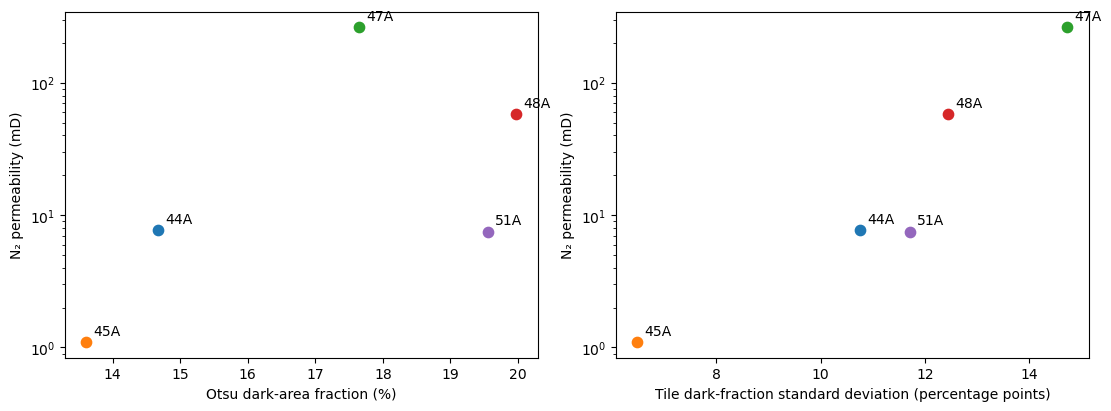

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

for _, record in comparison_df.iterrows():
    axes[0].scatter(record["otsu_dark_fraction_pct"], record["permeability_md"], s=55)
    axes[0].annotate(record["sample"],
                     (record["otsu_dark_fraction_pct"], record["permeability_md"]),
                     xytext=(5, 5), textcoords="offset points")
    axes[1].scatter(record["tile_fraction_std_pct"], record["permeability_md"], s=55)
    axes[1].annotate(record["sample"],
                     (record["tile_fraction_std_pct"], record["permeability_md"]),
                     xytext=(5, 5), textcoords="offset points")

axes[0].set(xlabel="Otsu dark-area fraction (%)", ylabel="N₂ permeability (mD)")
axes[1].set(xlabel="Tile dark-fraction standard deviation (percentage points)",
            ylabel="N₂ permeability (mD)")
for ax in axes:
    ax.set_yscale("log")

fig.savefig(figures_dir / "petrophysical-comparison.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

### Comparison of Samples 47A and 51A

Samples 47A and 51A have similar bulk helium porosity but very different permeability. Their image-derived dark-area fractions, tile variability, and local morphology provide descriptive comparisons, not causal evidence for the permeability difference. The preceding sensitivity test shows whether the local morphological descriptors vary under small changes in the Otsu threshold.

In [23]:
pair_df = comparison_df.set_index("sample").loc[["47A", "51A"]].reset_index()
pair_df.to_csv(tables_dir / "sample-47a-51a.csv", index=False)
display(pair_df.round(3))
print(f"Permeability ratio (47A / 51A): {permeability_md['47A'] / permeability_md['51A']:.1f}")

,sample,helium_porosity_pct,permeability_md,formation_factor,otsu_dark_fraction_pct,tile_fraction_std_pct,tile_fraction_p90_pct,crop_median_component_area_um2,crop_median_p90_distance_um
0,47A,17.4,263.0,21.4,17.653,14.730,38.754,0.182,12.140
1,51A,17.7,7.5,28.7,19.551,11.704,34.591,0.151,5.019


Permeability ratio (47A / 51A): 35.1


## Discussion and Limitations

The segmented class is defined by grayscale intensity, not independently verified mineral or pore labels. Otsu and histogram-valley thresholds can produce very different masks, especially for 44A and 45A; agreement between Otsu area fractions and helium porosity does not validate the masks. Morphological statistics exclude boundary-touching components, which tends to omit larger objects; Euclidean distances are affected by the artificial background at crop edges. The threshold sensitivity experiment checks the stability of local descriptors to ±5 grayscale levels, but does not establish their accuracy or representativeness. All local measurements come from three selected crops per specimen, whereas the tile maps describe full-image heterogeneity. Two-dimensional connected regions cannot establish a three-dimensional flow network. With only five specimens, the comparisons remain descriptive and do not support a permeability model.

## Conclusions

The workflow uses full-resolution intensity histograms, two thresholding strategies, local connected-component and distance-transform measurements, and full-image spatial tiling to describe dark regions in five BSE-SEM images. Otsu provides a reproducible reference but not a validated pore mask. Morphological sensitivity to small threshold changes is reported explicitly, alongside crop-boundary limitations. Samples 47A and 51A illustrate that similar bulk porosity and image dark-area fraction do not imply similar permeability; these two-dimensional descriptors cannot explain the difference causally. The results support a restrained, exploratory comparison rather than a three-dimensional connectivity or permeability prediction.